Notebook 1 — Data Exploration & Business Understanding

Objective

The objective of this notebook is to perform exploratory data analysis (EDA) on the Global Superstore dataset to understand business performance, customer behavior, sales trends, profitability drivers, and operational efficiency.

This analysis serves as the foundation for:

* feature engineering
* forecasting
* customer analytics
* churn simulation
* anomaly detection
* executive dashboards

Business Questions

This notebook aims to answer:

1. Which regions generate the highest sales and profit?
2. Which product categories perform best?
3. How do discounts affect profitability?
4. Are there seasonal sales patterns?
5. Which customers contribute most revenue?
6. Are there operational inefficiencies in shipping?
7. What anomalies or unusual trends exist in the data?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

In [4]:
orders = pd.read_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/Global_Superstore2.csv", encoding="latin1")
orders.shape

(51290, 24)

In [5]:
orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [6]:
orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [8]:
orders.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


Insight 1

Dataset Size: There are 51,290 total recorded transactions (based on the row count for Sales, Quantity, Discount, Profit, and Shipping Cost). However, only 9,994 transactions have a recorded Postal Code.

Sales Performance: The average sale amount is 246.49USD, with a median (50%) sale of 85.05USD. Individual transaction sizes vary drastically, ranging from a minimum of 0.44USD to a maximum of 22,638.48USD.

Profitability: The average profit per transaction is 28.61USDUSD, and the median profit is 9.24USD. At least 25% of all transactions yield 0.00USD or less in profit, with the worst-performing transaction resulting in a loss of 6,599.98USD. The maximum profit recorded for a single transaction is 8,399.98USD.

Discounting: The average discount applied to an order is 14.3%. For at least 50% of the transactions, no discount was applied (0.0%), while the maximum discount applied to a transaction reaches 85%.

Quantity:The average number of items per order is approximately 3.5 units. The minimum items ordered is 1, and the maximum is 14.

Logistics Costs: The average shipping cost is 26.38, with a median cost of 7.79USD. Shipping costs range from a minimum of 0.00USD to a maximum of 933.57USD.

---------------------------------------------------------------------

Data Quality Assessment

In [9]:
orders.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [10]:
missing_values = pd.DataFrame({"Missing Values": orders.isnull().sum(), "Percentage": (orders.isnull().sum() / len(orders)) * 100})
missing_values.sort_values(by="Percentage",ascending=False)

,Missing Values,Percentage
Postal Code,41296,80.51472
Row ID,0,0.00000
Region,0,0.00000
Shipping Cost,0,0.00000
Profit,0,0.00000
Discount,0,0.00000
Quantity,0,0.00000
Sales,0,0.00000
Product Name,0,0.00000
Sub-Category,0,0.00000


In [11]:
orders.duplicated().sum()

np.int64(0)

In [12]:
orders["Order Date"] = pd.to_datetime(orders["Order Date"])
orders["Ship Date"] = pd.to_datetime(orders["Ship Date"])

In [13]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

-------------------------------------------------------

Univariate Analysis

1. Sales Distribution 

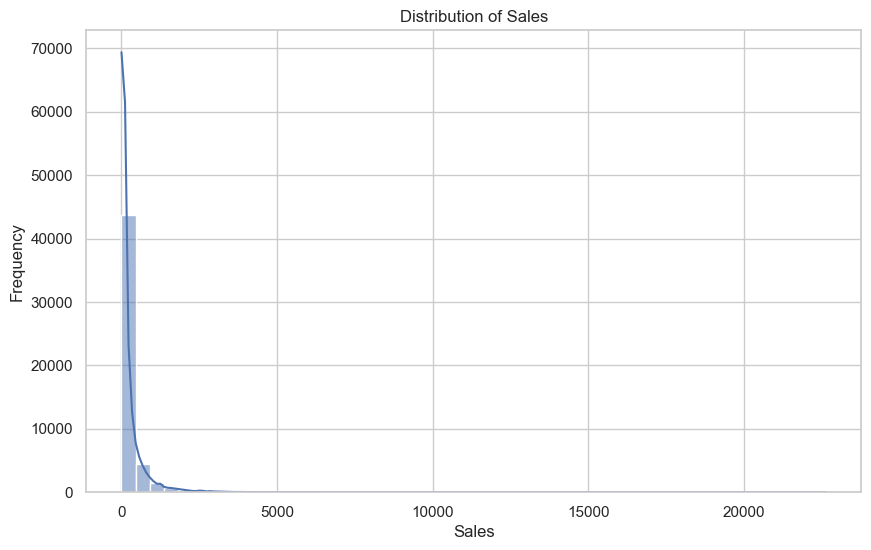

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(orders["Sales"],  bins=50, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

Insights 2 :

The visual distribution is heavily right-skewed (positively skewed), meaning that the vast majority of sales transactions are concentrated at the lower end of the scale, specifically near zero and under 1,000, where the frequency peaks dramatically at over 40,000 occurrences for the initial bin. As sales values increase along the x-axis, the frequency drops precipitously, forming a long, thin tail that stretches all the way out past 20,000. This indicates that while standard, low-value sales make up the bulk of the business volume, there are occasional, extreme high-value outliers occurring at a very low frequency, which is a highly common pattern in retail or transactional data.

 2. Profit Distribution

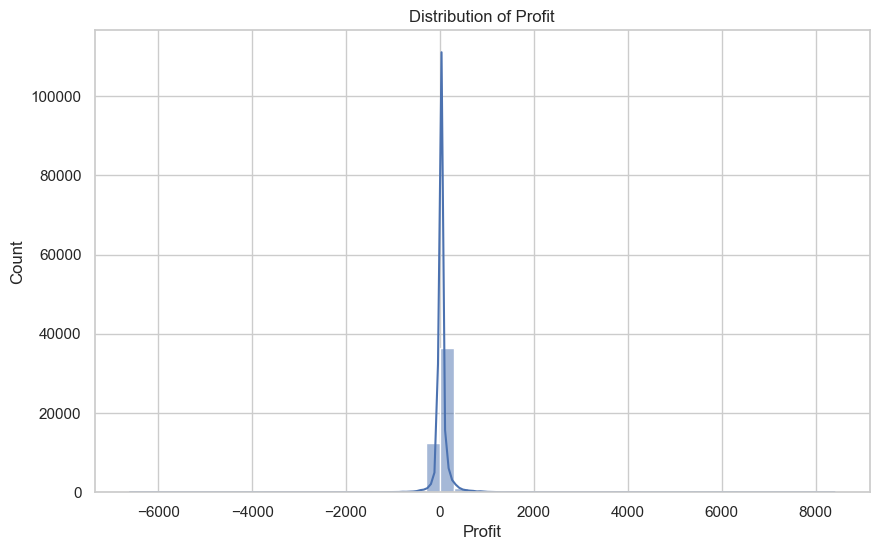

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(orders["Profit"],  bins=50, kde=True)
plt.title("Distribution of Profit")
plt.show()

Insights 3: 
The distribution is highly leptokurtic and exhibits a massive, sharp peak centered tightly around zero, with the count skyrocketing to over 110,000. This indicates that the overwhelming majority of transactions or observations result in little to no profit, essentially breaking even. The distribution features extremely long, thin tails extending symmetrically into both the negative territory (down to roughly -7,000, representing substantial losses) and the positive territory (up to nearly 9,000, representing substantial profits). This indicates that while standard operations consistently yield near-zero profit margins, the dataset contains notable, low-frequency outliers on both extreme ends of the financial spectrum.

 3. Discount Distribution 

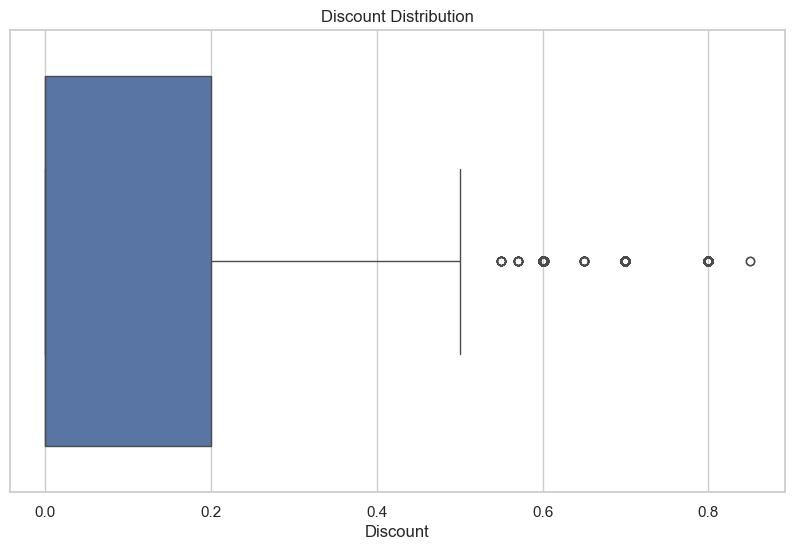

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x=orders["Discount"])
plt.title("Discount Distribution")
plt.show()

Insights 4 :

The main blue box spans from a discount rate of 0.0 (the minimum and first quartile, which are compressed together at the left boundary) up to a third quartile value of 0.2, indicating that the interquartile range (IQR) is tightly clustered and at least 75% of all transactions receive a discount of 20% or less. The vertical line representing the median sits right on the 0.2 mark, showing a heavily left-concentrated distribution where half of the data points fall exactly between 0% and 20% discount rates. The right whisker extends out to 0.5 (a 50% discount), marking the upper boundary for standard, non-outlier data. Beyond this whisker, individual open circles appear as statistical outliers, stretching from roughly 0.55 up to 0.85, which highlights that while steep discounts between 55% and 85% are occasionally offered, they represent rare exceptions to the company's standard discounting behavior

Bivariate Analysis

 1. Sales vs Profit

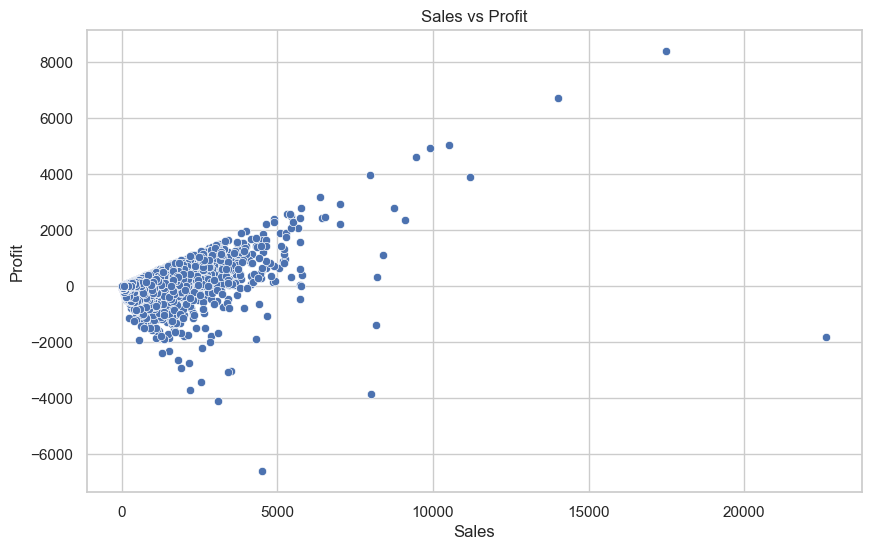

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=orders, x="Sales",  y="Profit")
plt.title("Sales vs Profit")
plt.show()

Insights 5

The data forms a distinct fan-shaped (heteroscedastic) pattern, starting tightly clustered near the origin where sales are low and variance is minimal, and spreading out dramatically as sales increase. A prominent, upward-sloping upper boundary of data points reveals a positive correlation where higher sales volume generally yields higher profits, peaking at over 8,000 in profit for a transaction near 17,500 in sales. However, the plot also highlights significant financial risk, as a substantial number of data points diverge downward into negative territory, indicating transactions that resulted in severe losses despite generating high revenue—such as an extreme outlier near 4,500 in sales that incurred a loss of over -6,000, and a massive transaction exceeding 22,500 in sales that failed to turn a profit, landing around -2,000

 2. Discount vs Profit

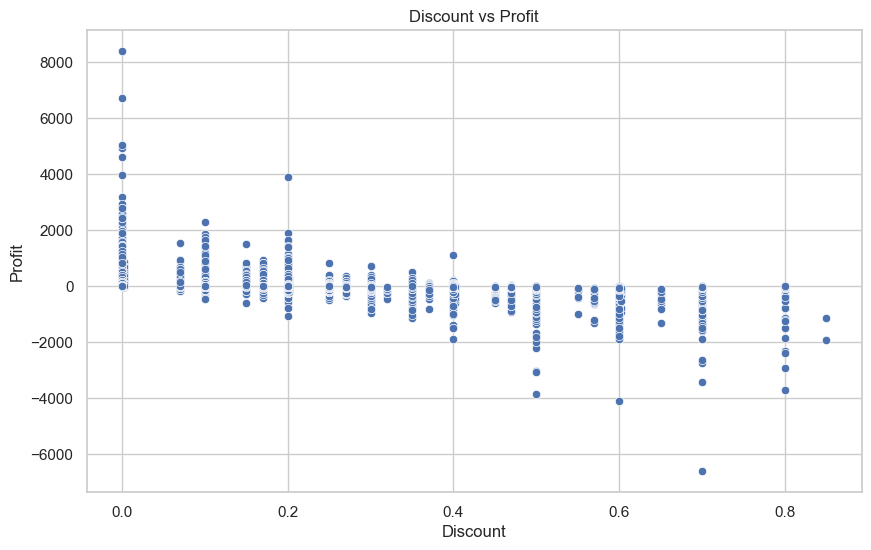

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=orders, x="Discount",  y="Profit")
plt.title("Discount vs Profit")
plt.show()

Insights 6

There is a clear and pronounced negative correlation between the two variables: as the discount rate increases along the x-axis, the maximum potential profit decreases, and the frequency and severity of financial losses worsen. At a 0.0 (0%) discount, profits hit their highest peak, reaching above 8,000 with zero recorded losses. However, once discounts surpass 0.2 (20%), the distribution visibly dips below the zero-profit line, and by the time discounts reach 0.5 or higher, positive profit margins virtually disappear, giving way to substantial losses—culminating in an extreme outlier at a 0.7 (70%) discount that incurred a loss exceeding -6,000.

Times Series Analysis

In [19]:
orders["Year"] = orders["Order Date"].dt.year
orders["Month"] = orders["Order Date"].dt.month
orders["Month Name"] = orders["Order Date"].dt.month_name()

 1. Monthly Sales Trend

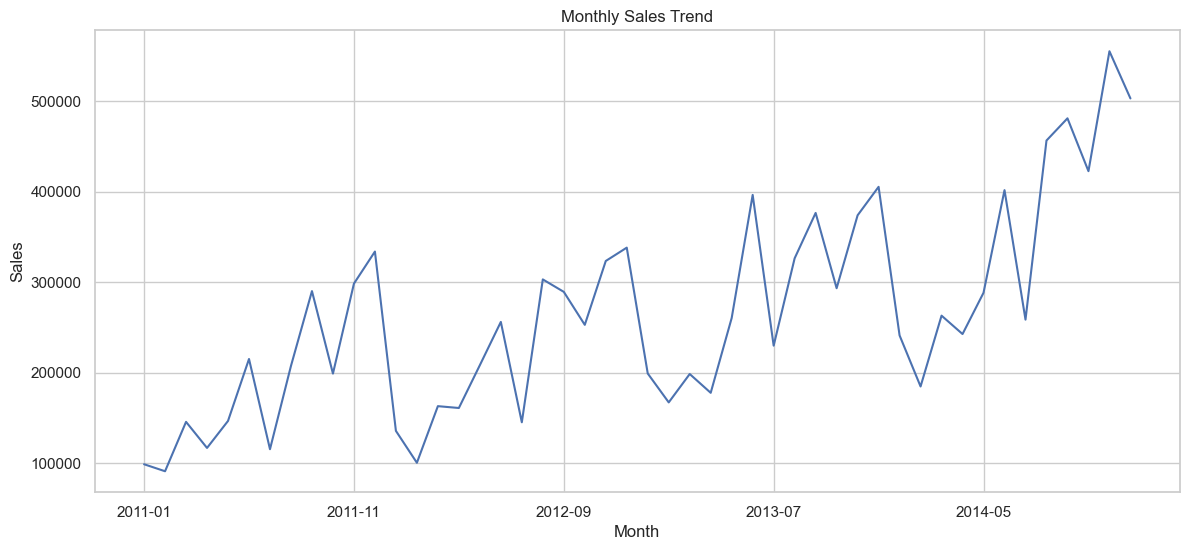

In [20]:
monthly_sales = (orders.groupby(orders["Order Date"].dt.to_period("M") )["Sales"] .sum())
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Insights 7
The data exhibits a clear, long-term upward secular trend, with baseline sales climbing from around 100,000 at the beginning of 2011 to peaking well over 500,000 by the end of 2014. Intertwined with this growth is a highly visible pattern of seasonality and cyclical volatility, characterized by sharp, recurring peaks followed by steep, dramatic drops roughly every twelve months—notably diving to near-baseline levels around the start of 2012 and 2013 before recovering. Despite these intense short-term fluctuations and periodic downturns, each consecutive annual peak rises higher than the last, confirming robust year-over-year growth and expanding market traction for the business over the four-year timeline.

 3. Monthly Profit Trend

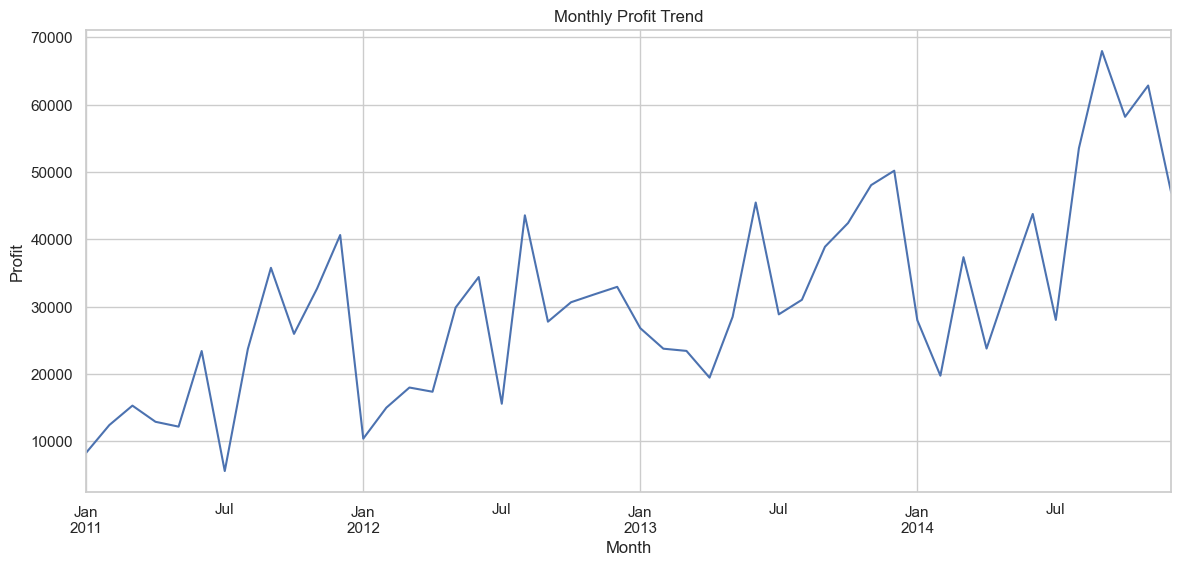

In [21]:
monthly_profit = ( orders.groupby(  orders["Order Date"].dt.to_period("M") )["Profit"]  .sum())
plt.figure(figsize=(14,6))
monthly_profit.plot()
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.show()

Insights 8

Similar to the corresponding sales data, the chart demonstrates a strong, long-term upward secular trend, with baseline profits rising from under 10,000 at the start of 2011 to a peak of nearly 70,000 in the latter half of 2014. This growth is heavily punctuated by cyclical seasonality, featuring predictable, sharp drawdowns that consistently occur around mid-year (such as the drop near July 2011 to the historical low of roughly 5,000) and immediately following the year-end holiday spikes around January of 2012, 2013, and 2014. Despite these recurring, highly volatile dips, the business demonstrates strong financial resilience, as each consecutive annual trough and peak establishes a higher floor and ceiling than those of the previous year, confirming sustained profit expansion over time.

Geographic Analysis

 1. Sales by Region 

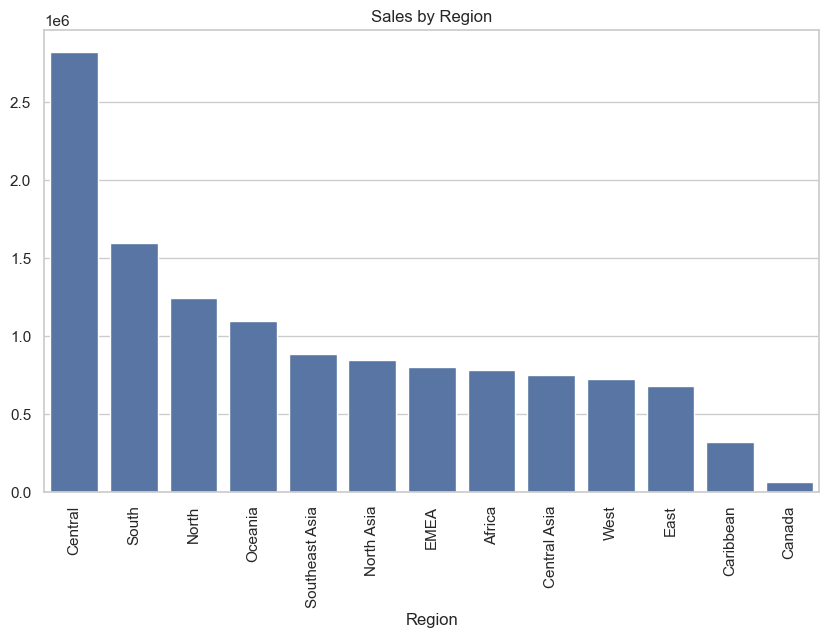

In [22]:
region_sales = (orders.groupby("Region")["Sales"].sum() .sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot( x=region_sales.index,  y=region_sales.values )
plt.xticks(rotation=90)
plt.title("Sales by Region")
plt.show()

Insight 9

The y-axis is scaled in millions , revealing a massive disparity between the company's top-performing and lowest-performing territories. The Central region stands out as the dominant revenue driver by a significant margin, single-handedly generating nearly 2.8 million in sales. A steep drop-off follows, with the South and North regions securing the second and third positions at roughly 1.6 million and 1.25 million, respectively. The middle tier of the chart features a relatively flat distribution where regions like Oceania, Southeast Asia, South Asia, EMEA, Africa, Central Asia, West, and East experience a gradual, stable decline, hovering within the 1.1 million to 700,000 range. In stark contrast, the lowest-performing markets are found at the far right of the chart, where the Caribbean  drops sharply to around 300,000, and Canada sits at the absolute bottom, contributing a negligible fraction of sales well under 100,000.

2. Profit by Region

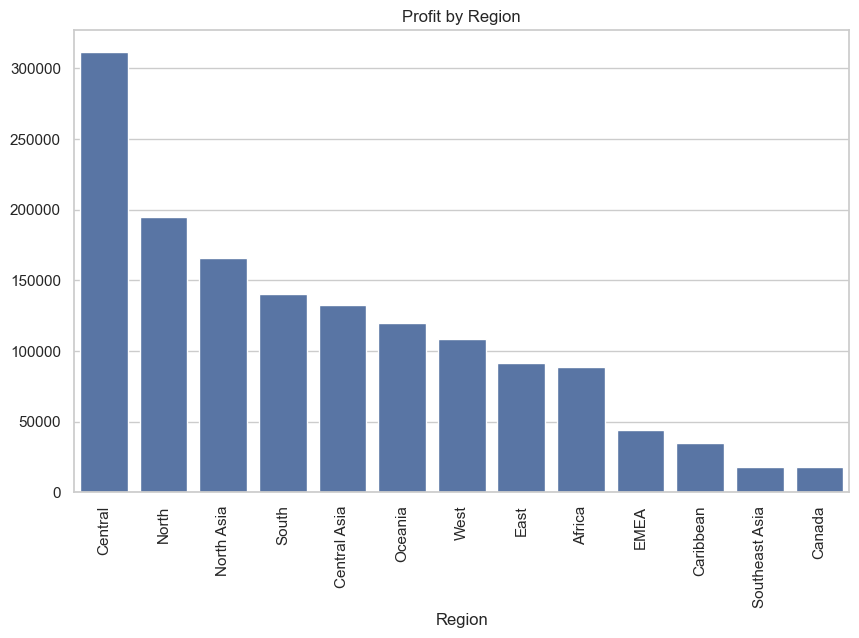

In [23]:
region_profit = (orders.groupby("Region")["Profit"].sum().sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot( x=region_profit.index,  y=region_profit.values )
plt.xticks(rotation=90)
plt.title("Profit by Region")
plt.show()

Insight 10 

Mirroring its performance in total revenue, the Central region is the undisputed financial powerhouse of the company, securing a massive lead by generating over 310,000 in profit. The subsequent positions show a steady, stepped decline, with the North and North Asia regions claiming the second and third spots at approximately 195,000 and 165,000, respectively. A middle tier composed of South, Southeast Asia, Oceania, West, East, and Africa shows a gradual and highly uniform contraction, with profits tapering down from around 140,000 to just under 90,000. In contrast, the lowest-earning territories drop off precipitously on the far right of the chart; EMEA and the Caribbean bring in a modest 44,000 and 35,000, while Central Asia and Canada anchor the very bottom of the distribution, each contributing a negligible and identical profit floor of under 20,000.

Product Performance Analysis

1. Sales by category

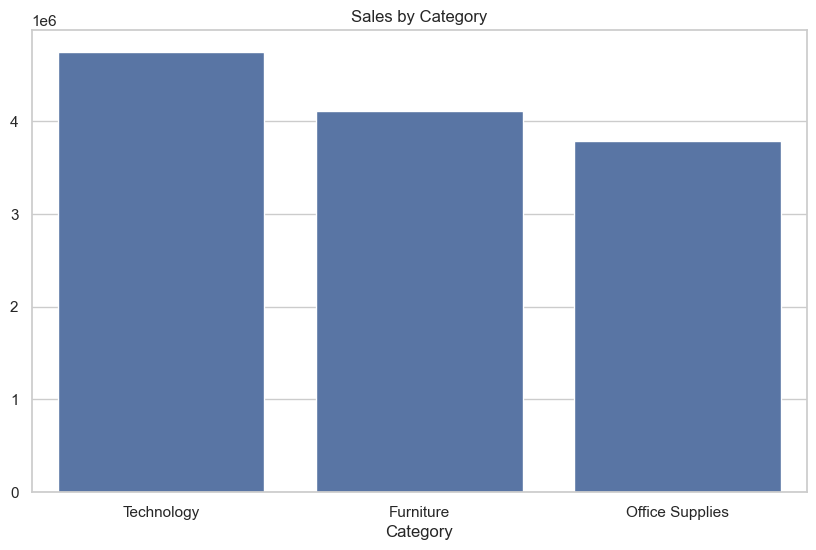

In [24]:
category_sales = (  orders.groupby("Category")["Sales"] .sum() .sort_values(ascending=False))
plt.figure(figsize=(10,6))
sns.barplot(  x=category_sales.index,  y=category_sales.values)
plt.title("Sales by Category")
plt.show()

Insights 11

Total sales revenue across three primary product sectors: Technology, Furniture, and Office Supplies. The y-axis is scaled in millions ($1\text{e}6$), revealing a relatively balanced but clearly tiered distribution of revenue. Technology emerges as the leading product sector, generating the highest sales volume at approximately 4.7 million. Furniture follows in the second position, pulling in a robust revenue total of about 4.1 million. Office Supplies anchors the trio as the lowest-performing category, though it still represents a major revenue stream by contributing roughly 3.8 million in sales. Overall, while Technology maintains the competitive edge, the minor variance between the tallest and shortest bars indicates that the company enjoys a highly diversified revenue model where all three product categories drive substantial, multi-million dollar market demand.

2. Profit by sub-category

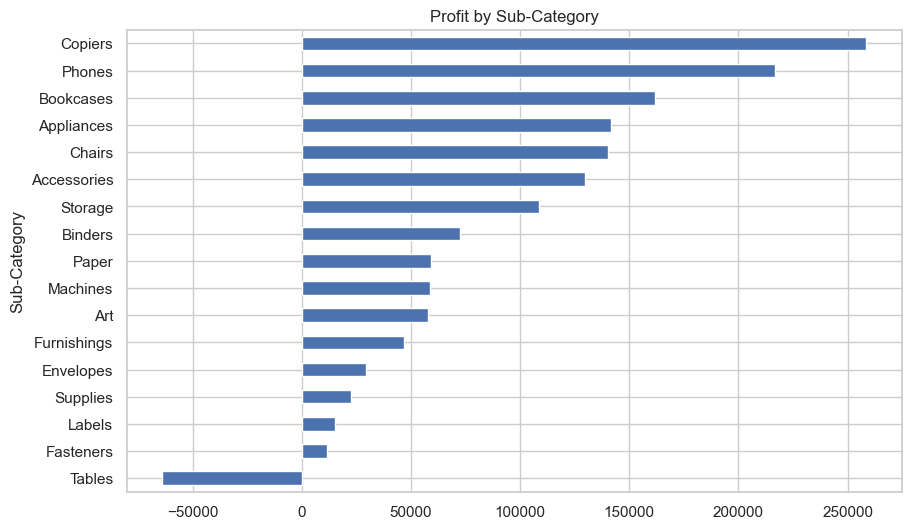

In [25]:
subcategory_profit = ( orders.groupby("Sub-Category")["Profit"] .sum()  .sort_values())
plt.figure(figsize=(10,6))
subcategory_profit.plot(kind="barh")
plt.title("Profit by Sub-Category")
plt.show()

Insight 12

The chart reveals a stark financial divide, with the vast majority of sub-categories generating positive returns, led by Copiers as the primary profit engine at over 250,000, followed closely by Phones at roughly 215,000 and Bookcases at around 160,000. Profits gradually taper down through mid-performing items like Appliances, Chairs, Accessories, and Storage, eventually flattening out into lower-tier contributors such as Labels and Fasteners, which bring in minor positive returns under 20,000. Crucially, the chart highlights a major operational vulnerability at the absolute bottom of the distribution: while most products remain firmly to the right of the zero-profit baseline, Tables completely diverges into negative territory on the far left, standing out as a severe outlier that has incurred a massive net loss of approximately -60,000.

--------------------------------------------

Customer Analysis

1. Top Customer by Sales 

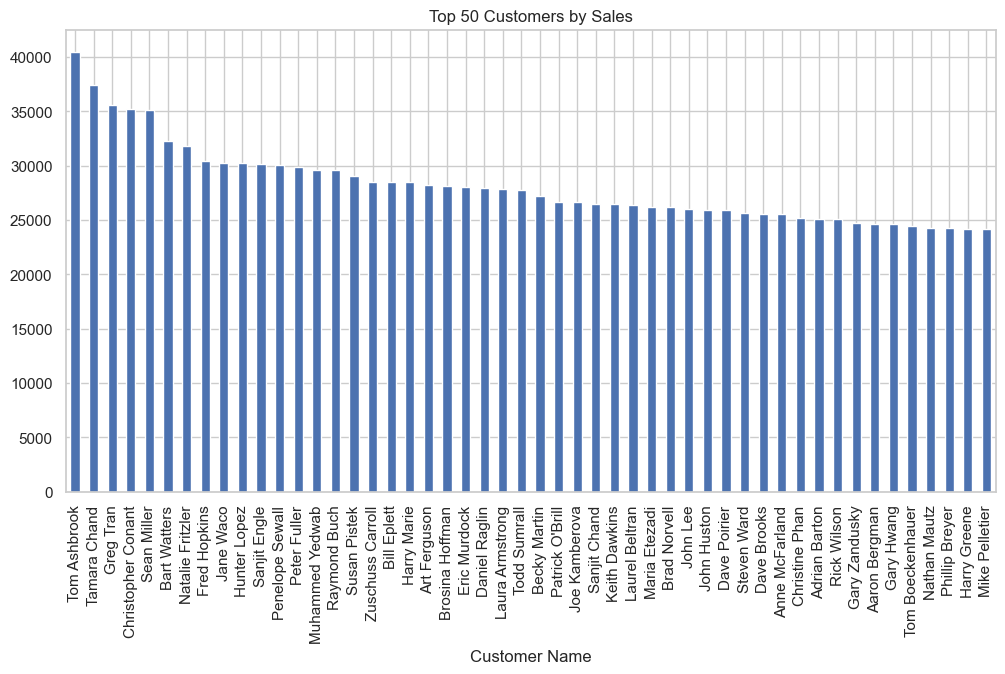

In [26]:
top_customers = (orders.groupby("Customer Name")["Sales"] .sum().sort_values(ascending=False).head(50))
plt.figure(figsize=(12,6))
top_customers.plot(kind="bar")
plt.title("Top 50 Customers by Sales")
plt.show()

Insights 13 

The distribution demonstrates a highly stable, uniform revenue base among the company's elite clientele, with a gentle, gradual sloping plateau across the majority of the chart. The absolute top customer leads the cohort at just over 40,000 in sales, followed by a minor, stepped decline for the next four top-performing clients who hover between 35,000 and 37,500. Beyond these initial top five bars, the revenue distribution enters a remarkably consistent run, with the remaining 45 customers tapering slowly from 30,000 down to a floor of approximately 24,000 at the far right. This tight, narrow spread among the top 50 accounts indicates that the business is not overly dependent on a single hyper-dominant client, but rather benefits from a well-distributed, high-volume revenue stream spread evenly across its primary customer base.

In [27]:
total_sales=orders["Sales"].sum()
total_sales_top50=top_customers.sum()
proportion= total_sales_top50/total_sales

print(proportion*100)



11.140332325987904


Insight 14 

This result delivers a crucial business insight regarding revenue concentration: the company's top 50 highest-paying clients account for just over 11% of total cumulative sales, confirming a highly decentralized, low-risk revenue model that is safely supported by a broad and diversified base of smaller transactions rather than being dangerously dependent on a few key accounts.

------------------------------------

Shipping & Operational Analysis 

1. Shipping Delay

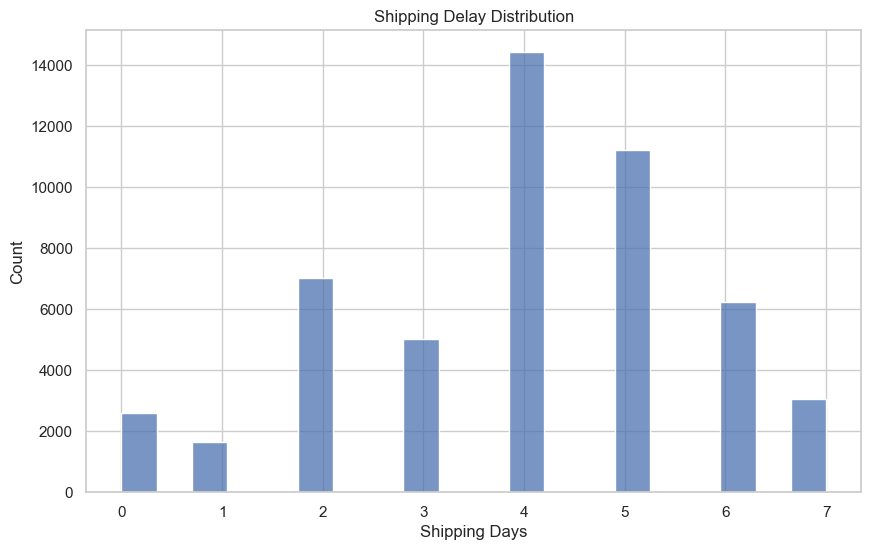

In [28]:
orders["Shipping Days"] = (orders["Ship Date"] - orders["Order Date"]).dt.days
plt.figure(figsize=(10,6))
sns.histplot( orders["Shipping Days"], bins=20)
plt.title("Shipping Delay Distribution")
plt.show()

Insights 15

The distribution is multimodal and non-normal, showing distinct operational variance across a fixed week-long window from 0 to 7 days. The absolute peak of the data occurs squarely at 4 shipping days, where the transaction count reaches its highest level at over 14,000 occurrences, followed closely by a strong secondary volume at 5 days with roughly 11,200 transactions. Interestingly, the distribution features a noticeable local peak at 2 days (around 7,000 transactions) and drops to a local low at 1 day (under 2,000 transactions), creating a jagged, uneven pattern rather than a smooth bell curve. The extreme ends of the spectrum show lower volumes, with immediate same-day or next-day shipping (0 to 1 days) and maximum delays (7 days) representing the rarest fulfillment scenarios, indicating that standard logistical operations consistently center around a 4-to-5 day delivery window.

2. Shipping mode analysis

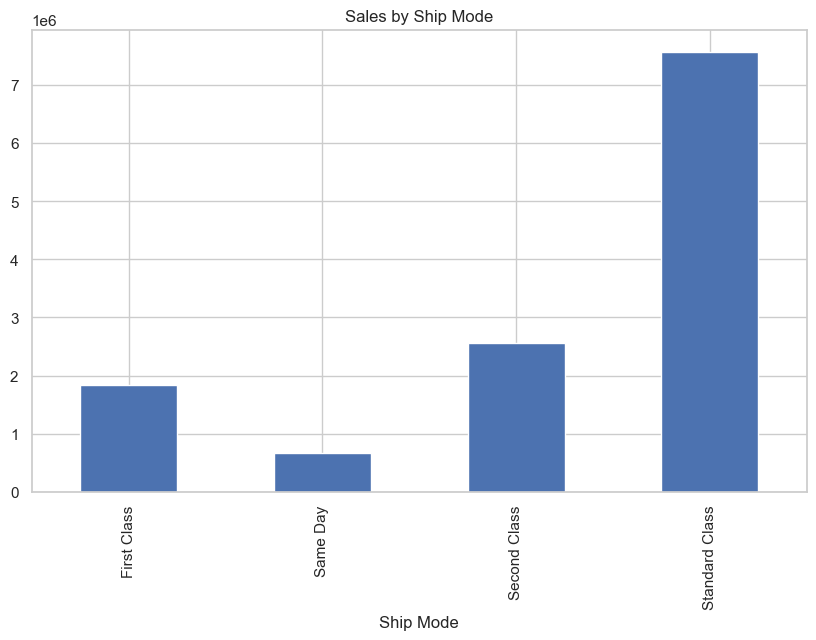

In [31]:
ship_mode_sales = ( orders.groupby("Ship Mode")["Sales"] .sum())
plt.figure(figsize=(10,6))
ship_mode_sales.plot(kind="bar")
plt.title("Sales by Ship Mode")
plt.show()

Insights 16 

vertical bar chart to compare the total sales volume generated across four different fulfillment methods: First Class, Same Day, Second Class, and Standard Class. The y-axis is scaled in millions, revealing that Standard Class is overwhelmingly the primary logistics choice, single-handedly dominating the company's fulfillment pipeline by driving a massive revenue total of roughly 7.5 million. In comparison, the other three fulfillment categories represent much smaller fractions of the business; Second Class sits as a distant second tier, pulling in about 2.5 million, followed by First Class at approximately 1.8 million. Same Day shipping anchors the far left of the chart as the lowest-performing option, generating a modest sales total under 1 million. This highly uneven distribution strongly indicates that customers are heavily skewed toward the most economical or standard shipping option, while premium, faster delivery tiers account for a significantly smaller share of total sales revenue.

-------------------------------------------

Profitability Analysis 

1. Profit Margin

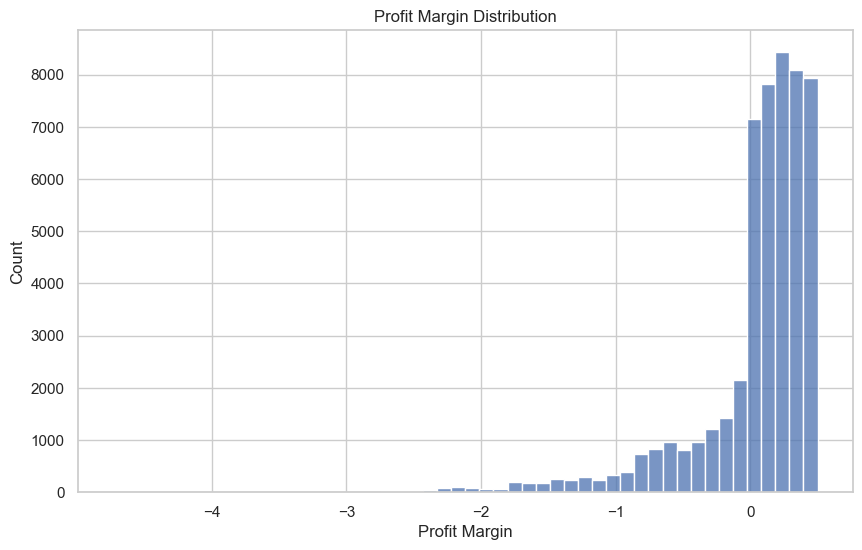

In [32]:
orders["Profit Margin"] = ( orders["Profit"] / orders["Sales"])
plt.figure(figsize=(10,6))
sns.histplot( orders["Profit Margin"],  bins=50)
plt.title("Profit Margin Distribution")
plt.show()

Insights 17

The visual distribution is heavily left-skewed (negatively skewed), with the overwhelming majority of transactions concentrated on the far right in positive territory, peaking sharply between 0.0 and 0.5 where counts consistently exceed 7,000 to 8,000 per bin. This concentration indicates that standard, day-to-day operations successfully generate healthy, positive profit margins. However, the distribution features a long, low-frequency tail that stretches far to the left into negative territory, trailing past -2.0 and extending toward -4.0. This thin tail highlights that while negative-margin transactions are relatively rare compared to profitable ones, the business occasionally experiences severe, outlying losses on specific orders that drastically underperform the operational norm.

2. Negetive Profit Orders

In [33]:
negative_profit_orders = orders[ orders["Profit"] < 0]
negative_profit_percentage = ( len(negative_profit_orders)  / len(orders)) * 100
negative_profit_percentage

24.457009163579645

Insight 18

This statistic provides a critical operational diagnostic: nearly a quarter of all processed transactions are failing to generate positive returns, indicating that while the overall business remains profitable on a macro scale, there is a widespread issue with underpriced items, high overhead costs, or over-discounting across individual line items that warrants strategic review.

--------------------------------------------

Correlation Analysis

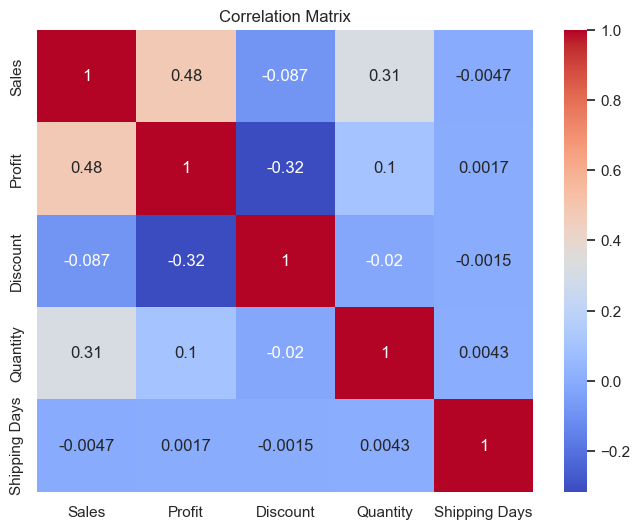

In [35]:
numeric_columns = orders[[  "Sales",  "Profit",  "Discount",  "Quantity",  "Shipping Days"]]
correlation_matrix = numeric_columns.corr()
plt.figure(figsize=(8,6))
sns.heatmap( correlation_matrix,  annot=True,  cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Insight 20 

The provided graph utilizes a color-coded heatmap to display the Pearson correlation coefficients between five key operational metrics: Sales, Profit, Discount, Quantity, and Shipping Days. The matrix features a perfect diagonal of dark red cells with a value of 1.0, representing each variable's correlation with itself, while the surrounding cells use a diverging cool-to-warm scale (blue for negative, gray for neutral, and red for positive relationships). The strongest linear connection in the dataset is a moderate positive correlation (0.48) between Sales and Profit, confirming that higher transactional revenue generally drives up bottom-line returns. Conversely, the matrix highlights a notable negative correlation (-0.32) between Discount and Profit, statistically validating that larger price cuts are associated with shrinking profit margins. Other variables, such as Shipping Days, show coefficient values nearly identical to zero (e.g., 0.0017 with Profit and -0.0047 with Sales), proving that delivery delays have virtually no linear relationship with the volume or financial success of the orders processed.

-------------------------------------------

Conclusion
This exploratory data analysis established a comprehensive understanding of the Global Superstore business environment.

Key findings include:
* strong seasonal sales behavior
* profitability challenges linked to discounting
* regional performance disparities
* customer concentration trends
* operational inefficiencies in shipping

These insights will guide the next stages of the Enterprise Retail Intelligence Platform, including:
* feature engineering
* customer segmentation
* churn simulation
* anomaly detection
* forecasting
* executive dashboard development

The notebook provides the analytical foundation required for enterprise-grade retail intelligence systems.